# 05 · Çoklu Karşılaştırma Düzeltmesi (Multiple Testing Correction)
**Statistical Inference Lab**

---
> **Bu notebook'ta ne öğreneceğiz?**  
> 01'de öğrendiğimiz $\alpha=0.05$ kuralı, **tek bir test** için tasarlanmıştı — "%5 ihtimalle
> yanlışlıkla anlamlı çıkar" diyorduk. Peki 20 test birden yaparsan? 100 test? Bu notebook'ta
> göreceğiz ki, çok sayıda test yaptığında yanlış pozitif olasılığı **katlanarak artıyor** —
> ve bunu düzeltmezsen, aslında hiçbir gerçek etkisi olmayan değişkenleri "anlamlı" diye
> rapor edebilirsin. Bu, 04'teki Kruskal-Wallis post-hoc önizlemesinde değindiğimiz konunun
> tam açılımı.

**Önkoşul:** Hipotez Testi (01), Nonparametrik Testler (04 — post-hoc önizlemesi)  
**Veri:**  
- Breast Cancer Wisconsin (Diagnostic) — `sklearn.datasets.load_breast_cancer()` (yerleşik, 569 hasta, 30 özellik)  
- `FIFA21_official_data.csv` — 17.108 futbolcu (çok sayıda ülke, ikili karşılaştırma senaryosu)  
**Araçlar:** Python (`statsmodels.stats.multitest`), R (base R `p.adjust`)

---
## 1 · Problem: Neden 20 Test Yaparsan Biri "Yanlışlıkla" Anlamlı Çıkar

$\alpha=0.05$ demek, **tek bir testte** %5 Tip I Hata (yanlış pozitif) riskini kabul ediyorum
demek. Ama $m$ tane **bağımsız** test yaparsan, "en az birinde" yanlış pozitif çıkma olasılığı
şu formülle büyür:
$$P(\text{en az 1 yanlış pozitif}) = 1-(1-\alpha)^m$$

**Sayısal tablo — bu formülü küçük $m$'lerle takip edelim:**

| $m$ (test sayısı) | $P(\text{en az 1 yanlış pozitif})$ |
|---|---|
| 1 | %5.0 |
| 5 | %22.6 |
| 10 | %40.1 |
| 20 | %64.2 |
| 50 | %92.3 |
| 100 | %99.4 |

**Sarsıcı sonuç:** 20 tamamen anlamsız (gerçekte hiçbir etkisi olmayan) değişkeni test edersen,
%64 ihtimalle en az biri "istatistiksel olarak anlamlı" çıkar — sırf şans eseri! Bu, veri
bilimindeki "p-hacking" ve "çoklu karşılaştırma" tuzaklarının matematiksel kökeni.

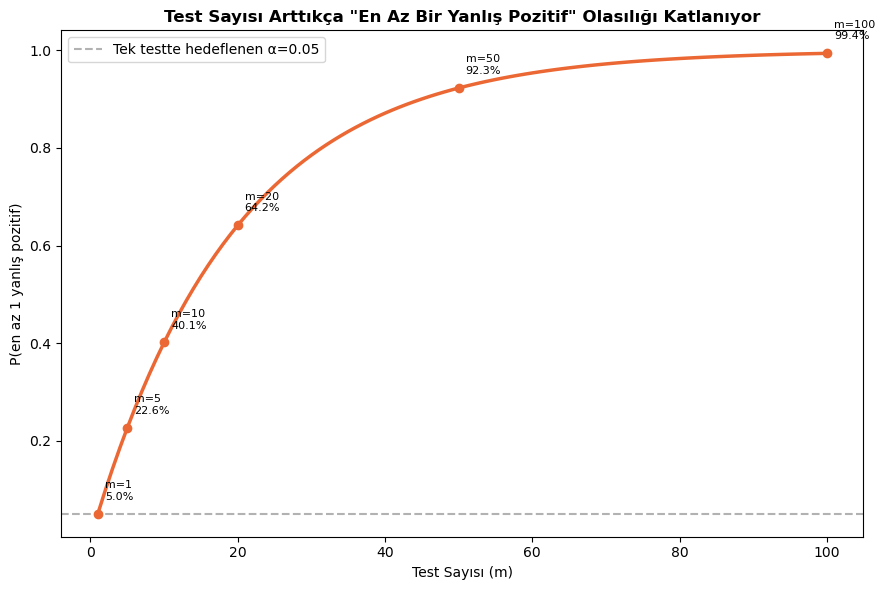

In [4]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.05
m_degerleri = np.arange(1, 101)
p_en_az_bir_hata = 1 - (1 - alpha)**m_degerleri

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(m_degerleri, p_en_az_bir_hata, color='#eb6834', linewidth=2.5)
for m_isaret in [1, 5, 10, 20, 50, 100]:
    p_isaret = 1 - (1-alpha)**m_isaret
    ax.scatter([m_isaret], [p_isaret], color='#eb6834', zorder=5)
    ax.annotate(f'm={m_isaret}\n{p_isaret:.1%}', (m_isaret, p_isaret),
                textcoords="offset points", xytext=(5, 10), fontsize=8)
ax.axhline(0.05, color='gray', linestyle='--', alpha=0.6, label='Tek testte hedeflenen α=0.05')
ax.set_xlabel('Test Sayısı (m)')
ax.set_ylabel('P(en az 1 yanlış pozitif)')
ax.set_title('Test Sayısı Arttıkça "En Az Bir Yanlış Pozitif" Olasılığı Katlanıyor', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2 · İki Farklı Düzeltme Felsefesi: FWER vs FDR

**FWER (Family-Wise Error Rate):** "En az bir yanlış pozitif olma olasılığını $\alpha$'nın
altında tutmak istiyorum" — çok **katı** bir hedef, tek bir yanlışa bile tahammülü yok.
**Bonferroni** bu felsefeyi uyguluyor.

**FDR (False Discovery Rate):** "Anlamlı bulduğum sonuçlar arasında, yanlış pozitiflerin
ORANINI $\alpha$'nın altında tutmak istiyorum" — daha **gevşek** bir hedef, "100 anlamlı
sonuç buldum, bunların en fazla %5'i yanlış olsun" diyor. **Benjamini-Hochberg (BH)** bu
felsefeyi uyguluyor.

**Pratik fark:** FWER (Bonferroni) çok muhafazakar — gerçek etkileri de "anlamsız" olarak
işaretleme riski (Tip II Hata) yüksek. FDR (BH) daha dengeli — daha fazla gerçek etkiyi
yakalıyor ama biraz daha fazla yanlış pozitife izin veriyor. Genomik/büyük-ölçekli
araştırmalarda genelde BH tercih edilir; küçük, kritik-öneme-sahip test sayılarında
(örn. bir ilacın güvenlik testi) Bonferroni'nin katılığı tercih edilebilir.

---
## 3 · Bonferroni Düzeltmesi: En Basit Çözüm

Formül son derece basit — eşiği test sayısına böl:
$$\alpha_{\text{düzeltilmiş}} = \frac{\alpha}{m}$$

Örnek: $m=20$ test, $\alpha=0.05$ ise, her testin **kendi** p-değeri artık
$0.05/20=0.0025$'in altında olmalı ki "anlamlı" sayılsın. Bu, her testi çok daha "zor"
bir eşikle karşı karşıya bırakıyor — bu yüzden **muhafazakar** (güç kaybına yol açan) bir
yöntem olarak biliniyor.

---
## 4 · Benjamini-Hochberg (BH) Prosedürü: Adım Adım

BH, Bonferroni'den daha karmaşık ama daha "akıllı" — sıralı p-değerlerine **artan** bir
eşik uyguluyor (Bonferroni'nin sabit eşiğinin aksine).

**Adım 1:** Tüm $m$ p-değerini küçükten büyüğe sırala: $p_{(1)} \le p_{(2)} \le \dots \le p_{(m)}$

**Adım 2:** Her sıra ($k$) için bir eşik hesapla: $\text{eşik}_k = \frac{k}{m}\times\alpha$

**Adım 3:** $p_{(k)} \le \text{eşik}_k$ şartını sağlayan **EN BÜYÜK** $k$'yı bul

**Adım 4:** $1$'den $k$'ya kadar olan TÜM testleri anlamlı kabul et (sadece $k$. testi değil!)

**Somut örnek** ($m=10$, $\alpha=0.05$, sıralı p-değerleri aşağıda):

| $k$ | $p_{(k)}$ | eşik $=\frac{k}{10}\times 0.05$ | $p_{(k)} \le$ eşik? |
|---|---|---|---|
| 1 | 0.001 | 0.005 | ✓ |
| 2 | 0.004 | 0.010 | ✓ |
| 3 | 0.006 | 0.015 | ✓ |
| 4 | 0.011 | 0.020 | ✓ |
| 5 | 0.019 | 0.025 | ✓ |
| 6 | 0.032 | 0.030 | ✗ |
| 7 | 0.041 | 0.035 | ✗ |
| 8 | 0.060 | 0.040 | ✗ |
| 9 | 0.150 | 0.045 | ✗ |
| 10 | 0.320 | 0.050 | ✗ |

En büyük $k$ (şart sağlanan) $=5$ → **ilk 5 test anlamlı kabul edilir** (sadece tek tek
$k \le 5$ değil, hepsi). Aşağıda bunu kodla doğrulayacağız — hem elle hem `statsmodels` ile
aynı 5 sonucu bulacağız.

---
## 5 · Bonferroni vs BH — Aynı Veride Ne Kadar Farklı Sonuç Verirler?

Yukarıdaki 10 p-değerlik örnekte:
- **Bonferroni** ($\alpha/10=0.005$ sabit eşik): sadece $p<0.005$ olanlar anlamlı → **2 test**
- **BH**: yukarıdaki adım adım prosedürle → **5 test**

Aynı veri, aynı $\alpha=0.05$ hedefi, **2.5 kat farklı sonuç.** Bu fark, neden yöntem seçiminin
(FWER mi FDR mü istiyorsun) kritik bir karar olduğunu gösteriyor — Python bölümünde bunu
gerçek veriyle (569 hastanın 30 özelliği) tekrar göreceğiz.

---
# 🐍 Python Uygulaması

5 adımda ilerleyeceğiz:
1. **Problemi Simülasyonla Kanıtlama** — Tamamen rastgele/ilişkisiz veride bile "yanlış" anlamlı sonuçlar
2. **Breast Cancer: 30 Özellik, Düzeltmesiz** — Kaç özellik "anlamlı" çıkıyor (düzeltmeden önce)
3. **Bonferroni Düzeltmesi** — Elle + `statsmodels` ile
4. **Benjamini-Hochberg Düzeltmesi** — Elle adım adım + `statsmodels` ile
5. **Gerçek Senaryo: FIFA'da Çoklu Ülke Karşılaştırması**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🎲 Python 1 — Problemi Simülasyonla Kanıtlama

**Ne yapıyoruz?**  
1000 kez tekrarlayan bir deney kuruyoruz: her seferinde 20 tane **tamamen rastgele, birbiriyle
hiçbir gerçek ilişkisi olmayan** değişken çifti üretip t-test yapıyoruz. Teorik olarak
%64 ihtimalle en az bir "yanlış" anlamlı sonuç bekliyoruz (Bölüm 1'deki tablo) — simülasyon
bunu doğrulayacak mı?

Teorik P(en az 1 yanlış pozitif), m=20: 0.6415
Simülasyon sonucu (1000 deney): 0.6030

Ortalama yanlış pozitif sayısı/deney: 0.95
(Teorik beklenen: m×α = 20×0.05 = 1.0)


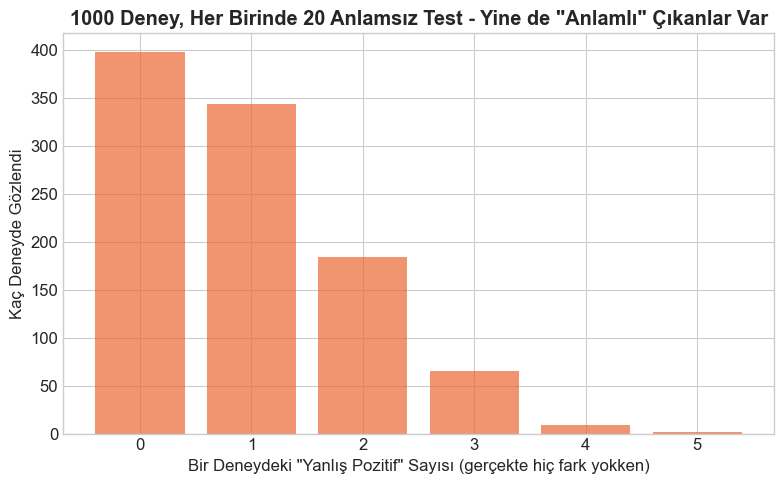


YORUM: Gruplar arasında GERÇEKTE hiçbir fark olmadığı halde (ikisi de N(0,1)'den),
simülasyonların büyük bölümünde en az bir test 'p<0.05' ile yanlışlıkla anlamlı çıktı.
Bu, düzeltme yapmadan çoklu test yapmanın somut tehlikesi.


In [3]:
rng = np.random.default_rng(42)
n_deney = 1000
m_test = 20
n_ornek = 50

en_az_bir_yanlis_pozitif_sayisi = 0
tum_yanlis_pozitif_sayilari = []

for _ in range(n_deney):
    yanlis_pozitif_bu_deneyde = 0
    for _ in range(m_test):
        # IKI GRUP DA AYNI DAGILIMDAN geliyor - aralarinda GERCEKTE hicbir fark yok
        grup1 = rng.normal(0, 1, n_ornek)
        grup2 = rng.normal(0, 1, n_ornek)
        _, p = stats.ttest_ind(grup1, grup2)
        if p < 0.05:
            yanlis_pozitif_bu_deneyde += 1
    tum_yanlis_pozitif_sayilari.append(yanlis_pozitif_bu_deneyde)
    if yanlis_pozitif_bu_deneyde > 0:
        en_az_bir_yanlis_pozitif_sayisi += 1

oran_simulasyon = en_az_bir_yanlis_pozitif_sayisi / n_deney
oran_teorik = 1 - (1-0.05)**m_test

print(f"Teorik P(en az 1 yanlış pozitif), m=20: {oran_teorik:.4f}")
print(f"Simülasyon sonucu ({n_deney} deney): {oran_simulasyon:.4f}")
print(f"\nOrtalama yanlış pozitif sayısı/deney: {np.mean(tum_yanlis_pozitif_sayilari):.2f}")
print("(Teorik beklenen: m×α = 20×0.05 = 1.0)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(tum_yanlis_pozitif_sayilari, bins=range(0, max(tum_yanlis_pozitif_sayilari)+2),
        color='#eb6834', alpha=0.7, align='left', rwidth=0.8)
ax.set_xlabel('Bir Deneydeki "Yanlış Pozitif" Sayısı (gerçekte hiç fark yokken)')
ax.set_ylabel('Kaç Deneyde Gözlendi')
ax.set_title(f'{n_deney} Deney, Her Birinde 20 Anlamsız Test - Yine de "Anlamlı" Çıkanlar Var', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nYORUM: Gruplar arasında GERÇEKTE hiçbir fark olmadığı halde (ikisi de N(0,1)'den),")
print("simülasyonların büyük bölümünde en az bir test 'p<0.05' ile yanlışlıkla anlamlı çıktı.")
print("Bu, düzeltme yapmadan çoklu test yapmanın somut tehlikesi.")

---
### 🩺 Python 2 — Breast Cancer: 30 Özellik, Düzeltmeden Önce

**Ne yapıyoruz?**  
Gerçek bir veri setinde (569 hasta, 30 hücre özelliği), malignant (kötü huylu) ve benign
(iyi huylu) gruplarının **her bir özellik için ayrı ayrı** t-testini yapıyoruz — düzeltme
yapmadan önce kaç tanesi "anlamlı" çıkıyor?

In [4]:
from sklearn.datasets import load_breast_cancer

veri = load_breast_cancer()
X = pd.DataFrame(veri.data, columns=veri.feature_names)
y = veri.target  # 0 = malignant, 1 = benign
print(f"Veri: {X.shape[0]} hasta, {X.shape[1]} özellik")
print(f"Malignant (0): {(y==0).sum()}, Benign (1): {(y==1).sum()}")

p_degerleri = []
for kolon in X.columns:
    malignant_deger = X[kolon][y == 0]
    benign_deger = X[kolon][y == 1]
    _, p = stats.ttest_ind(malignant_deger, benign_deger, equal_var=False)
    p_degerleri.append(p)

sonuc_df = pd.DataFrame({'ozellik': X.columns, 'p_degeri': p_degerleri}).sort_values('p_degeri')
print(f"\nDÜZELTMEDEN ÖNCE: {(sonuc_df['p_degeri'] < 0.05).sum()} / {len(sonuc_df)} özellik p<0.05 ile 'anlamlı'")
print("\nEn anlamlı 5 özellik:")
print(sonuc_df.head(5).to_string(index=False))
print("\nEn az anlamlı 5 özellik:")
print(sonuc_df.tail(5).to_string(index=False))

Veri: 569 hasta, 30 özellik
Malignant (0): 212, Benign (1): 357

DÜZELTMEDEN ÖNCE: 26 / 30 özellik p<0.05 ile 'anlamlı'

En anlamlı 5 özellik:
             ozellik     p_degeri
worst concave points 1.061454e-96
     worst perimeter 1.032730e-72
 mean concave points 3.127316e-71
        worst radius 3.556557e-71
      mean perimeter 1.023141e-66

En az anlamlı 5 özellik:
                ozellik  p_degeri
fractal dimension error  0.042202
       smoothness error  0.105297
 mean fractal dimension  0.766722
          texture error  0.835417
         symmetry error  0.887122


---
### 🔒 Python 3 — Bonferroni Düzeltmesi (Elle + `statsmodels`)

**Ne yapıyoruz?**  
30 özelliğin p-değerlerine Bonferroni düzeltmesi uygulayıp, düzeltmeden önce/sonra kaç
özelliğin "anlamlı" kaldığını karşılaştırıyoruz.

In [6]:
m = len(p_degerleri)
alpha = 0.05
alpha_duzeltilmis = alpha / m
print(f"Düzeltilmiş α: {alpha}/{m} = {alpha_duzeltilmis:.6f}")

# ===== ELLE =====
anlamli_elle = sonuc_df['p_degeri'] < alpha_duzeltilmis
print(f"\n[ELLE] Bonferroni sonrası anlamlı özellik sayısı: {anlamli_elle.sum()} / {m}")

# ===== STATSMODELS ILE DOGRULAMA =====
reddedildi, p_duzeltilmis, _, _ = multipletests(sonuc_df['p_degeri'].values, alpha=0.05, method='bonferroni')
print(f"[KÜTÜPHANE] Bonferroni sonrası anlamlı özellik sayısı: {reddedildi.sum()} / {m}")
print(f"İki yöntem örtüşüyor mü? {'EVET ✓' if anlamli_elle.sum() == reddedildi.sum() else 'HAYIR'}")

print(f"\nÖZET: Düzeltmeden önce {(sonuc_df['p_degeri']<0.05).sum()} özellik anlamlıydı,")
print(f"Bonferroni sonrası sadece {reddedildi.sum()} özellik anlamlı kaldı.")

Düzeltilmiş α: 0.05/30 = 0.001667

[ELLE] Bonferroni sonrası anlamlı özellik sayısı: 25 / 30
[KÜTÜPHANE] Bonferroni sonrası anlamlı özellik sayısı: 25 / 30
İki yöntem örtüşüyor mü? EVET ✓

ÖZET: Düzeltmeden önce 26 özellik anlamlıydı,
Bonferroni sonrası sadece 25 özellik anlamlı kaldı.


---
### 📈 Python 4 — Benjamini-Hochberg (Elle Adım Adım + `statsmodels`)

**Ne yapıyoruz?**  
Bölüm 4'teki BH prosedürünü, gerçek 30 p-değeri üzerinde **elle** uyguluyoruz (döngüyle,
sıralı eşikleri kontrol ederek), sonra `statsmodels` ile doğruluyoruz — ve Bonferroni ile
kaç özellik farkı olduğunu görüyoruz.

[ELLE] En büyük k (şartı sağlayan): 26
[ELLE] BH sonrası anlamlı özellik sayısı: 26 / 30
[KÜTÜPHANE] BH sonrası anlamlı özellik sayısı: 26 / 30
İki yöntem örtüşüyor mü? EVET ✓

=== ÜÇ YÖNTEMİN KARŞILAŞTIRMASI (30 özellik üzerinde) ===
Düzeltmesiz:  26 özellik anlamlı
Bonferroni:   25 özellik anlamlı (en muhafazakar)
BH (FDR):     26 özellik anlamlı (Bonferroni'den daha toleranslı)


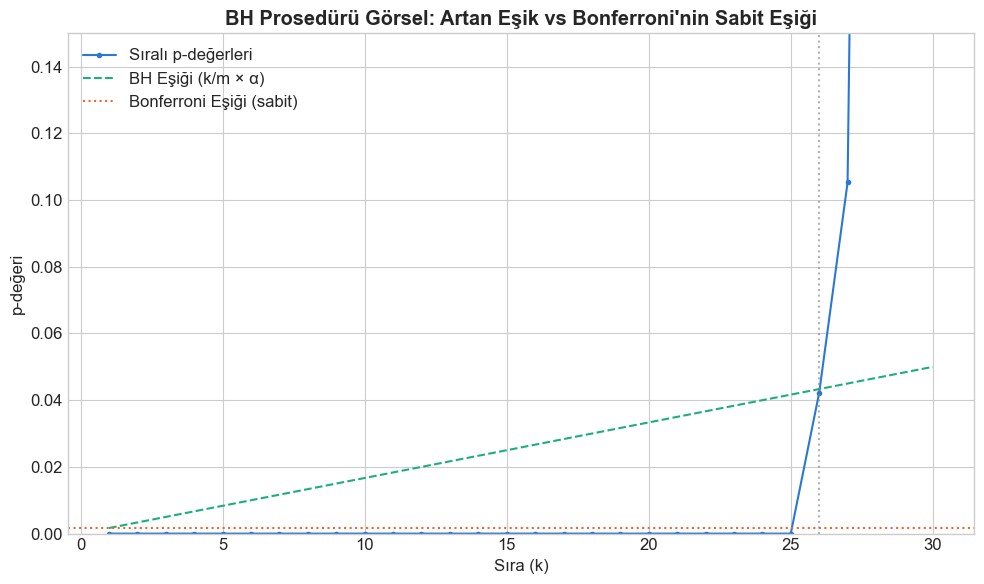


NOT: Bu gerçek veride Bonferroni ile BH arasındaki fark (25 vs 26), Bölüm 4'teki
sentetik örnekteki fark (2 vs 5) kadar dramatik değil. Sebebi: Breast Cancer'daki
etkiler ÇOK güçlü (bazı p-değerleri 1e-96 gibi) - bu kadar güçlü sinyal olduğunda
düzeltme yöntemi neredeyse hiçbir şeyi değiştirmiyor. Fark, ASIL sınırda/zayıf
sinyalli durumlarda (teoloji örneğindeki gibi) kritik hale geliyor - gerçek dünyada
da genomik gibi alanlarda binlerce ZAYIF sinyal test edildiğinde bu ayrım çok önemli.


In [7]:
p_sirali = np.sort(sonuc_df['p_degeri'].values)
m = len(p_sirali)
alpha = 0.05

# ===== ELLE BH PROSEDURU =====
esikler = (np.arange(1, m+1) / m) * alpha
sartı_saglayanlar = np.where(p_sirali <= esikler)[0]
if len(sartı_saglayanlar) > 0:
    k_max = sartı_saglayanlar.max() + 1  # 1-indeksli hale getir
else:
    k_max = 0
print(f"[ELLE] En büyük k (şartı sağlayan): {k_max}")
print(f"[ELLE] BH sonrası anlamlı özellik sayısı: {k_max} / {m}")

# ===== STATSMODELS ILE DOGRULAMA =====
reddedildi_bh, p_duzeltilmis_bh, _, _ = multipletests(sonuc_df['p_degeri'].values, alpha=0.05, method='fdr_bh')
print(f"[KÜTÜPHANE] BH sonrası anlamlı özellik sayısı: {reddedildi_bh.sum()} / {m}")
print(f"İki yöntem örtüşüyor mü? {'EVET ✓' if k_max == reddedildi_bh.sum() else 'HAYIR'}")

print(f"\n=== ÜÇ YÖNTEMİN KARŞILAŞTIRMASI (30 özellik üzerinde) ===")
print(f"Düzeltmesiz:  {(sonuc_df['p_degeri']<0.05).sum()} özellik anlamlı")
print(f"Bonferroni:   {reddedildi.sum()} özellik anlamlı (en muhafazakar)")
print(f"BH (FDR):     {reddedildi_bh.sum()} özellik anlamlı (Bonferroni'den daha toleranslı)")

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(1, m+1)
ax.plot(x_pos, p_sirali, 'o-', color='#2a78d6', markersize=3, label='Sıralı p-değerleri')
ax.plot(x_pos, esikler, '--', color='#1baf7a', label='BH Eşiği (k/m × α)')
ax.axhline(alpha/m, color='#eb6834', linestyle=':', label='Bonferroni Eşiği (sabit)')
ax.axvline(k_max, color='gray', linestyle=':', alpha=0.6)
ax.set_xlabel('Sıra (k)')
ax.set_ylabel('p-değeri')
ax.set_title('BH Prosedürü Görsel: Artan Eşik vs Bonferroni\'nin Sabit Eşiği', fontweight='bold')
ax.legend()
ax.set_ylim(0, 0.15)
plt.tight_layout()
plt.show()

print("\nNOT: Bu gerçek veride Bonferroni ile BH arasındaki fark (25 vs 26), Bölüm 4'teki")
print("sentetik örnekteki fark (2 vs 5) kadar dramatik değil. Sebebi: Breast Cancer'daki")
print("etkiler ÇOK güçlü (bazı p-değerleri 1e-96 gibi) - bu kadar güçlü sinyal olduğunda")
print("düzeltme yöntemi neredeyse hiçbir şeyi değiştirmiyor. Fark, ASIL sınırda/zayıf")
print("sinyalli durumlarda (teoloji örneğindeki gibi) kritik hale geliyor - gerçek dünyada")
print("da genomik gibi alanlarda binlerce ZAYIF sinyal test edildiğinde bu ayrım çok önemli.")

---
### ⚽ Python 5 — Gerçek Senaryo: FIFA'da Çoklu Ülke Karşılaştırması

**Ne yapıyoruz?**  
FIFA verisinde en çok oyuncuya sahip 6 ülkeyi seçip, her ikili çift için `Overall` (genel
reyting) farkını test ediyoruz. $\binom{6}{2}=15$ karşılaştırma çıkıyor — düzeltmeden
önce/sonra kaç tanesi anlamlı kalıyor?

In [8]:
fifa = pd.read_csv('data/FIFA21_official_data.csv')
print(f"Veri: {fifa.shape[0]} oyuncu")

en_cok_oyunculu_ulkeler = fifa['Nationality'].value_counts().head(6).index.tolist()
print(f"En çok oyunculu 6 ülke: {en_cok_oyunculu_ulkeler}")

from itertools import combinations
ikili_karsilastirmalar = list(combinations(en_cok_oyunculu_ulkeler, 2))
print(f"\nToplam ikili karşılaştırma sayısı: {len(ikili_karsilastirmalar)}")

sonuclar_fifa = []
for ulke1, ulke2 in ikili_karsilastirmalar:
    grup1 = fifa[fifa['Nationality'] == ulke1]['Overall']
    grup2 = fifa[fifa['Nationality'] == ulke2]['Overall']
    _, p = stats.mannwhitneyu(grup1, grup2)  # 04'teki nonparametrik tercihi burada da kullanalim
    sonuclar_fifa.append({'karsilastirma': f'{ulke1} vs {ulke2}', 'p_degeri': p})

fifa_df = pd.DataFrame(sonuclar_fifa).sort_values('p_degeri')

reddedildi_fifa_bonf, _, _, _ = multipletests(fifa_df['p_degeri'].values, alpha=0.05, method='bonferroni')
reddedildi_fifa_bh, _, _, _ = multipletests(fifa_df['p_degeri'].values, alpha=0.05, method='fdr_bh')

fifa_df['bonferroni_anlamli'] = reddedildi_fifa_bonf
fifa_df['bh_anlamli'] = reddedildi_fifa_bh

print(fifa_df.to_string(index=False))
print(f"\nDüzeltmesiz anlamlı: {(fifa_df['p_degeri']<0.05).sum()} / {len(fifa_df)}")
print(f"Bonferroni anlamlı: {reddedildi_fifa_bonf.sum()} / {len(fifa_df)}")
print(f"BH anlamlı: {reddedildi_fifa_bh.sum()} / {len(fifa_df)}")

Veri: 17108 oyuncu
En çok oyunculu 6 ülke: ['England', 'Germany', 'Spain', 'France', 'Brazil', 'Argentina']

Toplam ikili karşılaştırma sayısı: 15
       karsilastirma      p_degeri  bonferroni_anlamli  bh_anlamli
   England vs Brazil 9.601011e-162                True        True
    England vs Spain 1.059476e-104                True        True
   Germany vs Brazil  2.779481e-91                True        True
England vs Argentina  2.486822e-87                True        True
   England vs France  1.427571e-46                True        True
    France vs Brazil  9.016254e-46                True        True
    Germany vs Spain  3.433094e-35                True        True
Germany vs Argentina  3.159288e-34                True        True
  England vs Germany  2.162781e-24                True        True
     Spain vs Brazil  8.338198e-22                True        True
 Brazil vs Argentina  1.041590e-15                True        True
 France vs Argentina  1.119727e-10               

---
# 📊 R Uygulaması

R'ın **base R'a yerleşik** `p.adjust()` fonksiyonu, Bonferroni ve BH dahil 6 farklı düzeltme
yöntemini tek fonksiyonda topluyor (`method="bonferroni"` / `"BH"` / `"holm"` vb.) — hiçbir
ek paket gerekmez.

In [9]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 🩺 R 1 — Breast Cancer: 30 Özellik İçin p-değerleri

**Yeni R kavramı:** `sapply()` ile 30 kolon üzerinde döngü kurup her biri için t-test
p-değerini tek satırda topluyoruz.

Düzeltmeden önce anlamlı özellik sayısı: 26 / 30 


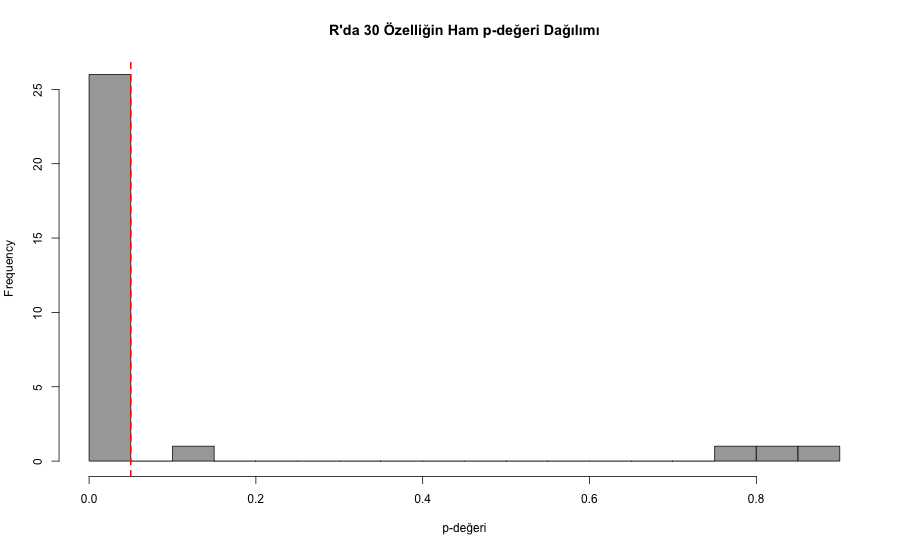

In [10]:
%%R -i X -i y -w 900 -h 550

y_r <- as.factor(y)
p_degerleri_r <- sapply(colnames(X), function(kolon) {
  t.test(X[[kolon]][y_r == 0], X[[kolon]][y_r == 1])$p.value
})

cat("Düzeltmeden önce anlamlı özellik sayısı:", sum(p_degerleri_r < 0.05), "/", length(p_degerleri_r), "\n")
hist(p_degerleri_r, breaks = 30, col = "#a8a8a8",
     main = "R'da 30 Özelliğin Ham p-değeri Dağılımı", xlab = "p-değeri")
abline(v = 0.05, col = "red", lwd = 2, lty = 2)

---
### 🔒 R 2 — Bonferroni ve BH ile Düzeltme

**Yeni R kavramı:** `p.adjust(p, method=...)` — tek fonksiyon çağrısı, Python'daki
`multipletests()` çağrısının R karşılığı.

In [11]:
%%R

p_bonf_r <- p.adjust(p_degerleri_r, method = "bonferroni")
p_bh_r <- p.adjust(p_degerleri_r, method = "BH")

cat("Bonferroni sonrası anlamlı:", sum(p_bonf_r < 0.05), "/", length(p_degerleri_r), "\n")
cat("BH sonrası anlamlı:", sum(p_bh_r < 0.05), "/", length(p_degerleri_r), "\n")
cat("\nPython'daki sonuçlarla karşılaştır - sayılar birebir örtüşmeli.\n")

# En anlamli 5 ozelligi goster (BH'ye gore siralanmis)
sirali_index <- order(p_bh_r)
cat("\nEn anlamlı 5 özellik (BH düzeltmeli p-değerine göre):\n")
for (i in sirali_index[1:5]) {
  cat(sprintf("%s: ham p=%.2e, BH-düzeltilmiş p=%.2e\n",
              colnames(X)[i], p_degerleri_r[i], p_bh_r[i]))
}

Bonferroni sonrası anlamlı: 25 / 30 
BH sonrası anlamlı: 26 / 30 

Python'daki sonuçlarla karşılaştır - sayılar birebir örtüşmeli.

En anlamlı 5 özellik (BH düzeltmeli p-değerine göre):
worst concave points: ham p=1.06e-96, BH-düzeltilmiş p=3.18e-95
worst perimeter: ham p=1.03e-72, BH-düzeltilmiş p=1.55e-71
mean concave points: ham p=3.13e-71, BH-düzeltilmiş p=2.67e-70
worst radius: ham p=3.56e-71, BH-düzeltilmiş p=2.67e-70
mean perimeter: ham p=1.02e-66, BH-düzeltilmiş p=6.14e-66


---
### ⚽ R 3 — FIFA: Çoklu Ülke Karşılaştırması

**Yeni R kavramı yok** — Python 5'teki mantığın R karşılığı, `combn()` fonksiyonu
Python'daki `itertools.combinations`'ın R karşılığı.

In [12]:
%%R -i fifa -w 900 -h 550

en_cok_ulkeler_r <- names(sort(table(fifa$Nationality), decreasing = TRUE)[1:6])
cat("En çok oyunculu 6 ülke:", en_cok_ulkeler_r, "\n")

ikili_r <- combn(en_cok_ulkeler_r, 2)
p_degerleri_fifa_r <- apply(ikili_r, 2, function(cift) {
  grup1 <- fifa$Overall[fifa$Nationality == cift[1]]
  grup2 <- fifa$Overall[fifa$Nationality == cift[2]]
  wilcox.test(grup1, grup2)$p.value
})

p_bonf_fifa_r <- p.adjust(p_degerleri_fifa_r, method = "bonferroni")
p_bh_fifa_r <- p.adjust(p_degerleri_fifa_r, method = "BH")

cat("\nDüzeltmesiz anlamlı:", sum(p_degerleri_fifa_r < 0.05), "/", length(p_degerleri_fifa_r), "\n")
cat("Bonferroni anlamlı:", sum(p_bonf_fifa_r < 0.05), "/", length(p_degerleri_fifa_r), "\n")
cat("BH anlamlı:", sum(p_bh_fifa_r < 0.05), "/", length(p_degerleri_fifa_r), "\n")
cat("\nPython 5'teki sonuçlarla karşılaştır.\n")

/opt/anaconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Loaned From". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


En çok oyunculu 6 ülke: England Germany Spain France Brazil Argentina 

Düzeltmesiz anlamlı: 14 / 15 
Bonferroni anlamlı: 14 / 15 
BH anlamlı: 14 / 15 

Python 5'teki sonuçlarla karşılaştır.


---
## ✏️ Egzersizler

---

### **E1 (Python).**
Python 1'deki simülasyonu $m=5$ ve $m=50$ ile tekrarla — "en az bir yanlış
pozitif" oranının teorik formülle ($1-(1-\alpha)^m$) ne kadar örtüştüğünü doğrula.


==== Simülasyon ile Anlamlı Test ====
Teorik P(en az 1 yanlış pozitif), m=5: 0.2262
Simülasyon sonucu (1000 deney): 0.2340
Teorik P(en az 1 yanlış pozitif), m=50: 0.9231
Simülasyon sonucu (1000 deney): 0.9280

Ortalama yanlış pozitif sayısı/deney (m=5): 0.25
(Teorik beklenen: m×α = 5×0.05 = 0.25)

Ortalama yanlış pozitif sayısı/deney (m=50): 2.54
(Teorik beklenen: m×α = 50×0.05 = 2.50)


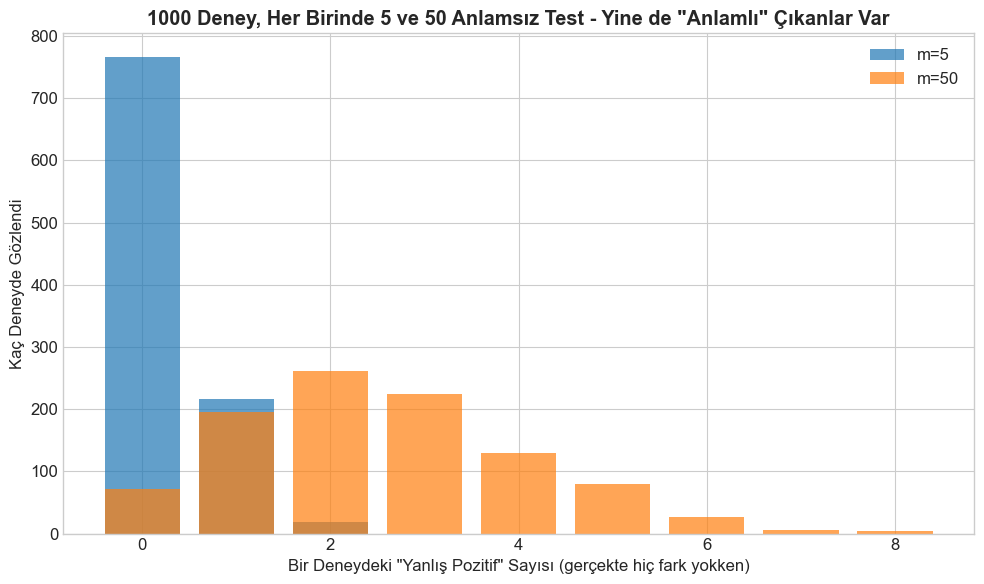

In [15]:
print("\n==== Simülasyon ile Anlamlı Test ====")

n_deney = 1000
m_testler = [5, 50]
n_ornek = 50

en_az_bir_yanlis_pozitif_sayilari = {m: 0 for m in m_testler}
tum_yanlis_pozitif_sayilari = {m: [] for m in m_testler}

for _ in range(n_deney):
    for m_test in m_testler:
        yanlis_pozitif_bu_deneyde = 0
        for _ in range(m_test):
            grup1 = np.random.normal(0, 1, n_ornek)
            grup2 = np.random.normal(0, 1, n_ornek)
            _, p = stats.ttest_ind(grup1, grup2)
            if p < 0.05:
                yanlis_pozitif_bu_deneyde += 1
        tum_yanlis_pozitif_sayilari[m_test].append(yanlis_pozitif_bu_deneyde)
        if yanlis_pozitif_bu_deneyde > 0:
            en_az_bir_yanlis_pozitif_sayilari[m_test] += 1

oran_simulasyon = {m: en_az_bir_yanlis_pozitif_sayilari[m] / n_deney for m in m_testler}
oran_teorik = {m: 1 - (1-0.05)**m for m in m_testler}

print(f"Teorik P(en az 1 yanlış pozitif), m=5: {oran_teorik[5]:.4f}")
print(f"Simülasyon sonucu ({n_deney} deney): {oran_simulasyon[5]:.4f}")
print(f"Teorik P(en az 1 yanlış pozitif), m=50: {oran_teorik[50]:.4f}")
print(f"Simülasyon sonucu ({n_deney} deney): {oran_simulasyon[50]:.4f}")
for m_test in m_testler:
    print(f"\nOrtalama yanlış pozitif sayısı/deney (m={m_test}): {np.mean(tum_yanlis_pozitif_sayilari[m_test]):.2f}")
    print(f"(Teorik beklenen: m×α = {m_test}×0.05 = {m_test*0.05:.2f})")

fig, ax = plt.subplots(figsize=(10, 6))
for m_test in m_testler:
    ax.hist(tum_yanlis_pozitif_sayilari[m_test], bins=range(0, max(tum_yanlis_pozitif_sayilari[m_test])+2),
            alpha=0.7, label=f'm={m_test}', align='left', rwidth=0.8)
ax.set_xlabel('Bir Deneydeki "Yanlış Pozitif" Sayısı (gerçekte hiç fark yokken)')
ax.set_ylabel('Kaç Deneyde Gözlendi')
ax.set_title(f'{n_deney} Deney, Her Birinde 5 ve 50 Anlamsız Test - Yine de "Anlamlı" Çıkanlar Var', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---

### **E2 (Python).**
Breast Cancer verisinde Bonferroni yerine `method='holm'` (Holm-Bonferroni,
Bonferroni'den biraz daha güçlü ama hâlâ FWER-kontrollü bir yöntem) kullan. Kaç özellik
anlamlı çıkıyor — Bonferroni ile BH arasında bir yerde mi?

In [17]:
print("\n ==== Egzersiz 2: Breast Cancer ile Holm-Bonferroni ====")

from sklearn.datasets import load_breast_cancer

veri = load_breast_cancer()
X = pd.DataFrame(veri.data, columns=veri.feature_names)
y = veri.target  # 0 = malignant, 1 = benign
print(f"Veri: {X.shape[0]} hasta, {X.shape[1]} özellik")
print(f"Malignant (0): {(y==0).sum()}, Benign (1): {(y==1).sum()}")

p_degerleri = []
for kolon in X.columns:
    malignant_deger = X[kolon][y == 0]
    benign_deger = X[kolon][y == 1]
    _, p = stats.ttest_ind(malignant_deger, benign_deger, equal_var=False)
    p_degerleri.append(p)

sonuc_df = pd.DataFrame({'ozellik': X.columns, 'p_degeri': p_degerleri}).sort_values('p_degeri')
print(f"\nDÜZELTMEDEN ÖNCE: {(sonuc_df['p_degeri'] < 0.05).sum()} / {len(sonuc_df)} özellik p<0.05 ile 'anlamlı'")
print("\nEn anlamlı 5 özellik:")
print(sonuc_df.head(5).to_string(index=False))
print("\nEn az anlamlı 5 özellik:")
print(sonuc_df.tail(5).to_string(index=False))

m = len(p_degerleri)
alpha = 0.05
alpha_duzeltilmis = alpha / m

# ===== STATSMODELS ILE HOLM-BONFERRONI =====
reddedildi_holm, p_duzeltilmis_holm, _, _ = multipletests(sonuc_df['p_degeri'].values, alpha=0.05, method='holm')
print(f"[KÜTÜPHANE] Holm-Bonferroni sonrası anlamlı özellik sayısı: {reddedildi_holm.sum()} / {m}")

print(f"\nÖZET: Düzeltmeden önce {(sonuc_df['p_degeri']<0.05).sum()} özellik anlamlıydı, düzeltmeden sonra {reddedildi_holm.sum()} özellik anlamlı oldu.")

print("\nHolm-Bonferroni yöntemi, Bonferroni yöntemine göre daha az muhafazakar bir düzeltme sağlar ve bu nedenle daha fazla özelliğin anlamlı olarak kabul edilmesine izin verir. Bu yöntem, p-değerlerini sıralar ve her bir p-değerini sırasına göre düzelterek anlamlılık testini gerçekleştirir.")




 ==== Egzersiz 2: Breast Cancer ile Holm-Bonferroni ====
Veri: 569 hasta, 30 özellik
Malignant (0): 212, Benign (1): 357

DÜZELTMEDEN ÖNCE: 26 / 30 özellik p<0.05 ile 'anlamlı'

En anlamlı 5 özellik:
             ozellik     p_degeri
worst concave points 1.061454e-96
     worst perimeter 1.032730e-72
 mean concave points 3.127316e-71
        worst radius 3.556557e-71
      mean perimeter 1.023141e-66

En az anlamlı 5 özellik:
                ozellik  p_degeri
fractal dimension error  0.042202
       smoothness error  0.105297
 mean fractal dimension  0.766722
          texture error  0.835417
         symmetry error  0.887122
[KÜTÜPHANE] Holm-Bonferroni sonrası anlamlı özellik sayısı: 25 / 30

ÖZET: Düzeltmeden önce 26 özellik anlamlıydı, düzeltmeden sonra 25 özellik anlamlı oldu.

Holm-Bonferroni yöntemi, Bonferroni yöntemine göre daha az muhafazakar bir düzeltme sağlar ve bu nedenle daha fazla özelliğin anlamlı olarak kabul edilmesine izin verir. Bu yöntem, p-değerlerini sıralar ve 

---

### **E3 (Python + R).**
FIFA verisinde 6 yerine 10 ülke seçip ($\binom{10}{2}=45$ karşılaştırma),
aynı analizi **hem Python'da hem R'da** tekrarla. Karşılaştırma sayısı arttıkça Bonferroni'nin
BH'ye göre ne kadar daha "katı" hale geldiğini gözlemle.

In [18]:
print("\n==== Egzersiz 3: FIFA ile Bonferroni ve BH ====")

top_10_oyunculu_ulkeler = fifa['Nationality'].value_counts().head(10).index.tolist()
print(f"Top 10 oyunculu ülkeler: {top_10_oyunculu_ulkeler}")

from itertools import combinations
ikili_karsilastirmalar = list(combinations(top_10_oyunculu_ulkeler, 2))
print(f"\nToplam ikili karşılaştırma sayısı: {len(ikili_karsilastirmalar)}")

sonuclar_fifa = []
for ulke1, ulke2 in ikili_karsilastirmalar:
    grup1 = fifa[fifa['Nationality'] == ulke1]['Overall']
    grup2 = fifa[fifa['Nationality'] == ulke2]['Overall']
    _, p = stats.mannwhitneyu(grup1, grup2)
    sonuclar_fifa.append({'karsilastirma': f'{ulke1} vs {ulke2}', 'p_degeri': p})

fifa_df = pd.DataFrame(sonuclar_fifa).sort_values('p_degeri')

reddedildi_fifa_bonf, _, _, _ = multipletests(fifa_df['p_degeri'].values, alpha=0.05, method='bonferroni')
reddedildi_fifa_bh, _, _, _ = multipletests(fifa_df['p_degeri'].values, alpha=0.05, method='fdr_bh')

fifa_df['bonferroni_anlamli'] = reddedildi_fifa_bonf
fifa_df['bh_anlamli'] = reddedildi_fifa_bh

print(fifa_df.to_string(index=False))
print(f"\nDüzeltmesiz anlamlı: {(fifa_df['p_degeri']<0.05).sum()} / {len(fifa_df)}")
print(f"Bonferroni anlamlı: {reddedildi_fifa_bonf.sum()} / {len(fifa_df)}")
print(f"BH anlamlı: {reddedildi_fifa_bh.sum()} / {len(fifa_df)}")


==== Egzersiz 3: FIFA ile Bonferroni ve BH ====
Top 10 oyunculu ülkeler: ['England', 'Germany', 'Spain', 'France', 'Brazil', 'Argentina', 'Italy', 'Netherlands', 'Mexico', 'Portugal']

Toplam ikili karşılaştırma sayısı: 45
           karsilastirma      p_degeri  bonferroni_anlamli  bh_anlamli
       England vs Brazil 9.601011e-162                True        True
        England vs Spain 1.059476e-104                True        True
       Germany vs Brazil  2.779481e-91                True        True
    England vs Argentina  2.486822e-87                True        True
     England vs Portugal  2.508714e-58                True        True
        England vs Italy  7.422614e-52                True        True
        Brazil vs Mexico  3.212909e-51                True        True
       England vs France  1.427571e-46                True        True
        France vs Brazil  9.016254e-46                True        True
        Germany vs Spain  3.433094e-35                True        

In [19]:
%%R -i fifa -w 900 -h 550

top_10_ulkeler_r <- names(sort(table(fifa$Nationality), decreasing = TRUE)[1:10])
cat("Top 10 oyunculu ülkeler:", top_10_ulkeler_r, "\n")

ikili_r <- combn(top_10_ulkeler_r, 2)
p_degerleri_fifa_r <- apply(ikili_r, 2, function(cift) {
  grup1 <- fifa$Overall[fifa$Nationality == cift[1]]
  grup2 <- fifa$Overall[fifa$Nationality == cift[2]]
  wilcox.test(grup1, grup2)$p.value
})

p_bonf_fifa_r <- p.adjust(p_degerleri_fifa_r, method = "bonferroni")
p_bh_fifa_r <- p.adjust(p_degerleri_fifa_r, method = "BH")

cat("\nDüzeltmesiz anlamlı:", sum(p_degerleri_fifa_r < 0.05), "/", length(p_degerleri_fifa_r), "\n")
cat("Bonferroni anlamlı:", sum(p_bonf_fifa_r < 0.05), "/", length(p_degerleri_fifa_r), "\n")
cat("BH anlamlı:", sum(p_bh_fifa_r < 0.05), "/", length(p_degerleri_fifa_r), "\n")

/opt/anaconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Loaned From". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


Top 10 oyunculu ülkeler: England Germany Spain France Brazil Argentina Italy Netherlands Mexico Portugal 

Düzeltmesiz anlamlı: 40 / 45 
Bonferroni anlamlı: 37 / 45 
BH anlamlı: 40 / 45 


---

### **E4 (R).**
`p.adjust()`'ın desteklediği diğer yöntemleri (`"hochberg"`, `"BY"`) breast cancer
verisinde dene, hepsinin anlamlı bulduğu özellik sayısını bir tabloda karşılaştır — en
muhafazakardan en toleranslıya doğru sırala.

Düzeltmesiz anlamlı: 26 / 30 
Hochberg anlamlı: 25 / 30 
BY anlamlı: 25 / 30 
[1] "\n Hochberg vs. Bonferroni: Hochberg yöntemi, Bonferroni'ye göre kesinlikle daha az muhafazakardır ve daha yüksek güç (power) sağlar. Her ikisi de Aile Boyu Hata Oranını (FWER) kontrol eder. Hochberg, p-değerlerini büyükten küçüğe sıralayarak (adım-aşağı/step-down) kontrol gerçekleştirir."
[1] "\n BY (Benjamini-Yekutieli) vs. BH: BY yöntemi, BH'ye göre daha muhafazakardır ve özellikle bağımlı testler için uygundur. BY, FDR'yi kontrol eder ve BH'ye göre daha az anlamlı sonuç verir. BH, bağımsız veya pozitif bağımlı testler için uygundur ve daha fazla anlamlı sonuç sağlar."
[1] "\n Muhafazakarlık Sıralaması Yaparsak: Bonferroni > BY > Hochberg > BH. Bu sıralama, her yöntemin anlamlı sonuç üretme olasılığına göre yapılmıştır. Bonferroni en muhafazakar, BH ise en toleranslıdır."


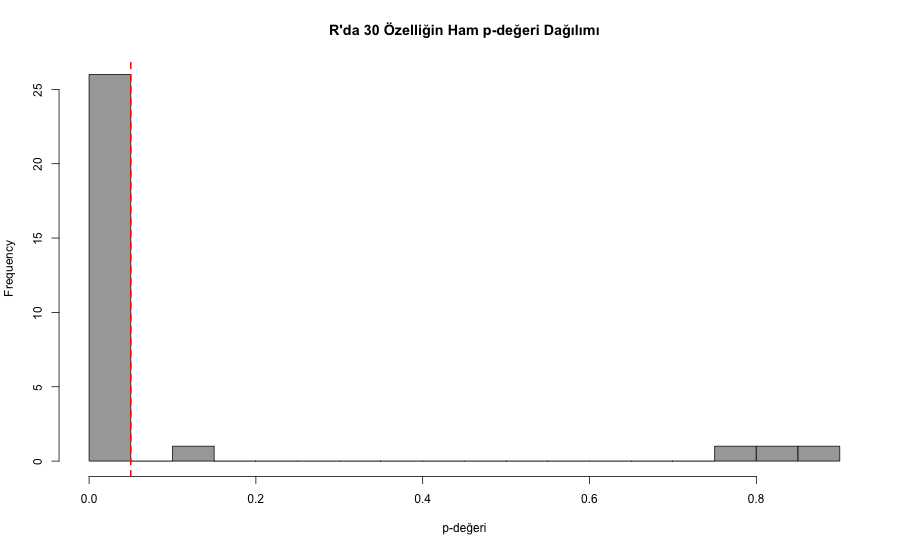

In [23]:
%%R -i X -i y -w 900 -h 550

y_r <- as.factor(y)

p_cancer_r <- sapply(colnames(X), function(kolon) {
  t.test(X[[kolon]][y_r == 0], X[[kolon]][y_r == 1])$p.value
})

p_hochberg_r <- p.adjust(p_cancer_r, method = "hochberg")
p_by_r <- p.adjust(p_cancer_r, method = "BY")

cat("Düzeltmesiz anlamlı:", sum(p_cancer_r < 0.05), "/", length(p_cancer_r), "\n")
cat("Hochberg anlamlı:", sum(p_hochberg_r < 0.05), "/", length(p_cancer_r), "\n")
cat("BY anlamlı:", sum(p_by_r < 0.05), "/", length(p_cancer_r), "\n")

hist(p_cancer_r, breaks = 30, col = "#a8a8a8",
     main = "R'da 30 Özelliğin Ham p-değeri Dağılımı", xlab = "p-değeri")
abline(v = 0.05, col = "red", lwd = 2, lty = 2)

print("\n Hochberg vs. Bonferroni: Hochberg yöntemi, Bonferroni'ye göre kesinlikle daha az muhafazakardır ve daha yüksek güç (power) sağlar. Her ikisi de Aile Boyu Hata Oranını (FWER) kontrol eder. Hochberg, p-değerlerini büyükten küçüğe sıralayarak (adım-aşağı/step-down) kontrol gerçekleştirir.")

print("\n BY (Benjamini-Yekutieli) vs. BH: BY yöntemi, BH'ye göre daha muhafazakardır ve özellikle bağımlı testler için uygundur. BY, FDR'yi kontrol eder ve BH'ye göre daha az anlamlı sonuç verir. BH, bağımsız veya pozitif bağımlı testler için uygundur ve daha fazla anlamlı sonuç sağlar.")

print("\n Muhafazakarlık Sıralaması Yaparsak: Bonferroni > BY > Hochberg > BH. Bu sıralama, her yöntemin anlamlı sonuç üretme olasılığına göre yapılmıştır. Bonferroni en muhafazakar, BH ise en toleranslıdır.")

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 10 | Hipotez testi temelleri |
| [Benjamini & Hochberg (1995) — Orijinal Makale](https://www.jstor.org/stable/2346101) | — | FDR kavramının tanıtıldığı klasik makale |
| [statsmodels multitest Dokümantasyonu](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html) | Kütüphane | Bu notebook'ta kullanılan ana araç |
| [Seeing Theory](https://seeing-theory.brown.edu/frequentist-inference) | Frequentist Inference | İnteraktif |
| [Breast Cancer Wisconsin (Diagnostic)](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-wisconsin-diagnostic-dataset) | Veri | sklearn built-in, orijinal kaynak UCI |
| [FIFA 21 Complete Player Dataset](https://www.kaggle.com/datasets/aayushmishra1512/fifa21-official-dataset) | Veri | FIFA21_official_data.csv kaynağı |